# Przepływ optyczny

In [156]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

root_path = ""

## Implementacja metody blokowej

Text(0.5, 1.0, 'J')

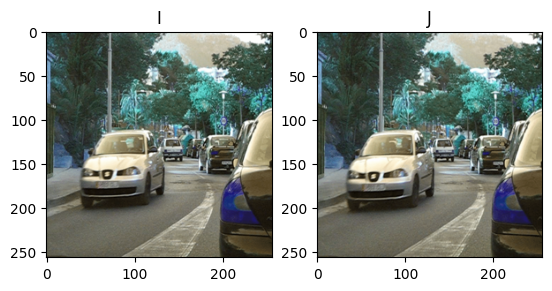

In [157]:
I = cv2.imread(root_path + "cm1.png")
J = cv2.imread(root_path + "cm2.png")

fig, axes = plt.subplots(1, 2)
axes[0].imshow(I)
axes[0].set_title("I")
axes[1].imshow(J)
axes[1].set_title("J")

Text(0.5, 1.0, 'Gray Diff')

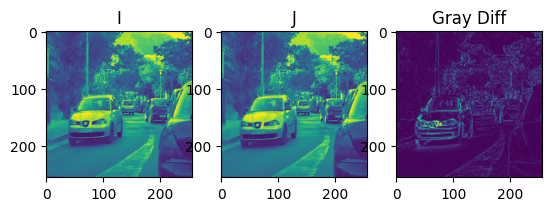

In [158]:
I_G = cv2.cvtColor(I, cv2.COLOR_BGR2GRAY)
J_G = cv2.cvtColor(J, cv2.COLOR_BGR2GRAY)
I_J_diff_G = cv2.absdiff(I_G, J_G)

fig, axes = plt.subplots(1, 3)
axes[0].imshow(I_G)
axes[0].set_title("I")
axes[1].imshow(J_G)
axes[1].set_title("J")
axes[2].imshow(I_J_diff_G)
axes[2].set_title("Gray Diff")

In [159]:
class OpticalFlowByMe:
    def __init__(self):
        pass

    def block_method(self, I: np.ndarray, J: np.ndarray, W2=3, dY=3, dX=3):
        if not isinstance(I , np.ndarray) or not isinstance(J , np.ndarray):
            print("Wrong type")
            return None
        if not I.shape == J.shape:
            print("Shape not matching")
            return None

        I_dXdt = np.zeros((I.shape[0], I.shape[1]))
        I_dYdt = np.zeros((I.shape[0], I.shape[1]))
        
        for row in range(2*dX, I.shape[0] - 2*dX):
            for col in range(2*dY, I.shape[1] - 2*dY):
                
                IO: np.ndarray = np.float32(I[row-W2:row+W2+1,col-W2:col+W2+1])
                flow_map:dict = {}

                for ddX in range(-dX, dX+1):
                    contexRow = row+ddX
                    # if ddX+row>I.shape[0]:
                    #     ddX = I.shape[0]
                    # elif ddX+row<0:
                    #     ddX = 0

                    for ddY in range(-dY, dY+1):
                        contexCol = col+ddY
                        # if ddY+col>I.shape[0]:
                        #     ddY = I.shape[0]
                        # elif ddY+col<0:
                        #     ddY = 0

                        JO: np.ndarray = np.float32(J[contexRow-W2:contexRow+W2+1,contexCol-W2:contexCol+W2+1])
                        flow_map[np.sqrt(np.sum((np.square(JO-IO))))] = (ddX, ddY)

                minimal_diff = min(flow_map.keys())
                (I_dXdt[row, col], I_dYdt[row, col]) = flow_map[minimal_diff]

        return (I_dXdt, I_dYdt)


    def calcHSV(self, I_flow):
        (I_dXdt, I_dYdt) = I_flow

        minmax = [np.min(I_dXdt), np.min(I_dYdt), np.max(I_dXdt), np.max(I_dYdt)]
        print(max(np.abs(minmax)))
        I_dXdt = I_dXdt/(np.max(np.abs(minmax)))
        I_dYdt = I_dYdt/(np.max(np.abs(minmax)))

        fig, axes = plt.subplots(1, 2)
        axes[0].imshow(cv2.cvtColor((I_dXdt*255).astype(np.uint8), cv2.COLOR_GRAY2BGR))
        axes[0].set_title("dX")
        axes[1].imshow(cv2.cvtColor((I_dYdt*255).astype(np.uint8), cv2.COLOR_GRAY2BGR))
        axes[1].set_title("dY")

        magnitude = np.sqrt(np.square(I_dXdt.astype(np.float64)) + np.square(I_dYdt.astype(np.float64)))
        angle = np.arctan2(I_dXdt.astype(np.float64), I_dYdt.astype(np.float64)) 

        hue = np.mod(np.divide(angle, np.pi) * 180 + 180, 360)
        hue = cv2.normalize(hue, None, 0, 255, norm_type=cv2.NORM_MINMAX).astype(np.uint8)

        saturation = cv2.normalize(magnitude, None, 0, 255, norm_type=cv2.NORM_MINMAX)
        mag_norm = 255


        hsv_image = np.zeros((I_dXdt.shape[0], I_dXdt.shape[1], 3), dtype=np.uint8)
        hsv_image[:, :, 0] = hue   
        hsv_image[:, :, 1] = saturation   
        hsv_image[:, :, 2] = mag_norm

        return hsv_image
       
    def piramid_block(self, I, J, maxscale = 3, W2 = 3):

        I_flow = [np.zeros((I.shape[0], I.shape[1]), dtype=np.float64), np.zeros((I.shape[0], I.shape[1]), dtype=np.float64)]

        for scale in range(maxscale):
            pow_scale = np.pow(2, scale)

            I_scaled = cv2.resize ( I, None , fx = np.pow(2.0, -scale) , fy = np.pow(2.0, -scale))
            J_scaled = cv2.resize ( J, None , fx = np.pow(2.0, -scale) , fy = np.pow(2.0, -scale))

            I_flow_scaled = self.block_method(I_scaled, J_scaled)

            I_flow_scaled_0 = I_flow_scaled[0]
            I_flow_scaled_1 = I_flow_scaled[1] 

            # I_flow_scaled_1 = cv2.GaussianBlur(I_flow_scaled[1], (2*W2+1, 2*W2+1), W2)
            # I_flow_scaled_0 = cv2.GaussianBlur(I_flow_scaled[0], (2*W2+1, 2*W2+1), W2)

            I_flow_rescaled_0 = cv2.resize(I_flow_scaled_0, None, fx=pow_scale, fy=pow_scale, interpolation=cv2.INTER_LINEAR)
            I_flow_rescaled_1 = cv2.resize(I_flow_scaled_1, None, fx=pow_scale, fy=pow_scale, interpolation=cv2.INTER_LINEAR)


            I_flow[0] = I_flow[0] + pow_scale * I_flow_rescaled_0
            I_flow[1] = I_flow[1] + pow_scale * I_flow_rescaled_1
        
        return I_flow

            

    
optfl = OpticalFlowByMe()


In [160]:
I_flow = optfl.block_method(I, J, W2 = 5, dX= 5, dY=5)

5.0


Text(0.5, 1.0, 'I_flow_HSV')

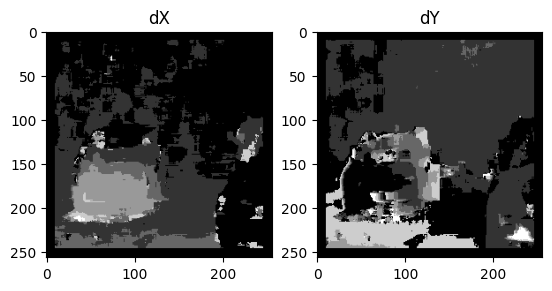

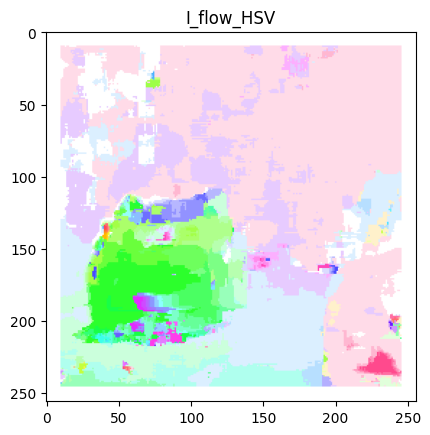

In [161]:
I_flow_HSV = optfl.calcHSV(I_flow)

I_flow_HSV = cv2.cvtColor(I_flow_HSV, cv2.COLOR_HSV2BGR)
fig, axes = plt.subplots()
axes.imshow(I_flow_HSV)
axes.set_title("I_flow_HSV")

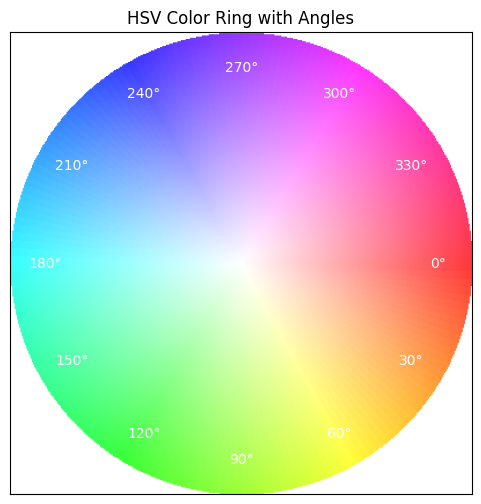

In [162]:
# Create coordinate grid
size = 400  # Image size
radius = size // 2
Y, X = np.meshgrid(np.arange(size) - radius, np.arange(size) - radius, indexing='xy')

# Compute polar coordinates
angle = (-1*(np.arctan2(Y, X) * 180 / np.pi)+90) % 360  # Angle in degrees (0-360)
distance = np.sqrt(X**2 + Y**2)

# Create HSV image (H: 0-179 in OpenCV)
hsv_image = np.zeros((size, size, 3), dtype=np.uint8)
hsv_image[..., 0] = (angle / 2).astype(np.uint8)  # Hue
hsv_image[..., 1] = np.where(distance < radius, distance, 0)  # Saturation
hsv_image[..., 2] =  255 # Value (keep ring)

# Convert to BGR for display
bgr_image = cv2.cvtColor(hsv_image, cv2.COLOR_HSV2RGB)

# Plot the image
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(bgr_image)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("HSV Color Ring with Angles")

# Annotate angles
for angle in range(0, 360, 30):
    rad = np.deg2rad(angle)
    x = radius + int(radius * 0.85 * np.cos(rad))
    y = radius + int(radius * 0.85 * np.sin(rad))
    ax.text(x, y, f"{angle}°", color="white", fontsize=10, ha="center", va="center")

plt.show()


## Implementacja wyliczania w wielu skalach

In [163]:
maxscale = 3
I_flow_pir = optfl.piramid_block(I, J, maxscale=maxscale)

19.375


Text(0.5, 1.0, 'I_flow_HSV')

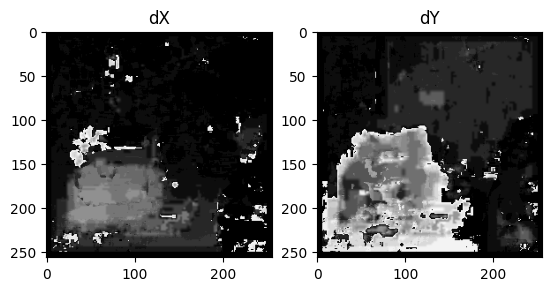

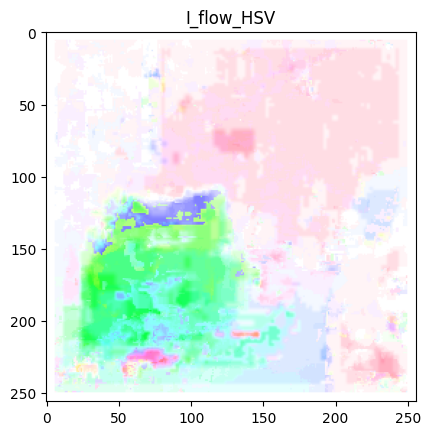

In [164]:
I_flow_HSV_pir = optfl.calcHSV(I_flow_pir)

I_flow_HSV_pir = cv2.cvtColor(I_flow_HSV_pir, cv2.COLOR_HSV2BGR)
fig, axes = plt.subplots()
axes.imshow(I_flow_HSV_pir)
axes.set_title("I_flow_HSV")